In [1]:
# PREPROCESSING CODE FOR IMAGING DATA with Behaviour
# Creates CSV, aligned the time events, runs suite2p and calculate dff for all cells
# Creates an analysis folder & saves necessary files for each recording session
# # This code creates necessary behaviour & imaging files
# It should work for any given task recorded in Dual2p or Packer 1 scope
# Requires MATLAB integration, and uses getBehavData matlab function
# 
# 30/08/2025 HA
%reload_ext autoreload
%autoreload 2

#make data file
print( "Takes <30s. However, it might take >1 mins or so if network is busy...")
import glob
import sys,os, glob, shutil
import pandas as pd
from datetime import datetime
import numpy as np
import main_funcs as mfun
import plot_funcs as pfun
import utils_funcs as utils # utils is from Vape - catcher file: 
import matplotlib.pyplot as plt
from scipy.stats import zscore
import pickle
import time
from LakLabAnalysis.Utility.extract_paq_events import extract_paq_data_frame
import LakLabAnalysis.Utility.utils_funcs as utils_laklab
from tifffile import TiffFile, imread, imwrite
import imageio.v2 as imageio
print('All libraries are loaded correctly.')
# set matlab API - I dont think we need MATLAB, if we need, uncomment
# import matlab.engine
# eng = matlab.engine.start_matlab()
# print('Matlab engine is set correctly.')


Takes <30s. However, it might take >1 mins or so if network is busy...
All libraries are loaded correctly.


In [ ]:

# TRY THIS - IF DO NOT WORK< CREATE YOUR INFO (MOST LIKELY WONT WORK AS PATHS ARE DIFFERENT) - THIS INFO FILE IS CREATED FOR THE RELEVANT ANIMAL, SO IT SHOULD WORK
# repo_analysis_path =  r'\\Qnap-Al001\LakGuest\Yuliia\sideBiasLateralization\analysis\info.pkl'
# info = pickle.load(open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info.pkl'), 'rb'))
# print('Info file is loaded correctly - Total recording sessions:', len(info.recordingList))

# CREATE INFO FOR THE RELEVANT ANIMAL - THIS TAKES 3mins for 4 animals, so be patient!
animalList= ['MAT057', 'MAT058','MAT068', 'MAT069']#,'MAT057','MAT058', 'MAT067', 'MAT068','MAT069']#] #
#'MAT038','MAT039', 'MAT045', 'MAT046','MAT066'
#,'HA011','HAT009','HAT010,'MBL015','MBL014',]

# Done:MBL014 & HAT009- completely bad ignore! 
info = mfun.analysis(animalList=animalList)
info.recordingList = info.recordingList[
    (info.recordingList['performance'] > 50) &
    (info.recordingList['twoP']) &
    (info.recordingList['duration'] > 20)
    ].reset_index(drop=True)
info = mfun.update_info(info)
print('Total Session fits the selection: ' +  str(info.recordingList.shape[0]))

Env: decMaking
Computer: Huriye Windows
Most likely expRef does not match Z:\MAT057\2025-11-05\1\2025-11-05_1_MAT057_Block.mat: not enough values to unpack (expected 3, got 2)
Total Session fits the selection: 66


In [5]:
# Check if pupil data extraction is complete - if a folder exist with sesionName in this folder yes, if not, no
pupilExtractedPath  = r'\\Qnap-Al001\LakGuest\Yuliia\sideBiasLateralization\analysis'
for ind, recordingDate in enumerate(info.recordingList.recordingDate):
    sessionName = info.recordingList.sessionName[ind]
    if os.path.exists(os.path.join(pupilExtractedPath, sessionName)):
        info.recordingList.loc[ind, 'pupilExtracted'] = 1
    else:
        info.recordingList.loc[ind, 'pupilExtracted'] = 0
print('Pupil data extraction is checked. Pupil data extracted:', info.recordingList.pupilExtracted.sum())



Pupil data extraction is checked. Pupil data extracted: 11.0


In [45]:
# Plotting params
pfun.set_figure()

## Parameters
fps = 15
fRate = 2000/fps
responsiveness_test_duration = 1000.0 #in ms 
responsiveness_test_duration_frames = int(np.ceil(responsiveness_test_duration/fRate))
pre_frames    = 2000.0# in ms
pre_frames    = int(np.ceil(pre_frames/fRate))
post_frames   = 6000.0 # in ms
post_frames   = int(np.ceil(post_frames/fRate))
analysisWindowDur = 750 # in ms
analysisWindowDur = int(np.ceil(analysisWindowDur/fRate))
simulationDur_ms = 2000.0 # in ms 
simulationDur  = int(np.ceil(simulationDur_ms/fRate))
duration ='5'

params ={}
params['fps'] = fps
params['fRate'] = fRate
params['responsiveness_test_duration'] = responsiveness_test_duration
params['responsiveness_test_duration_frames'] = responsiveness_test_duration_frames
params['pre_frames'] = pre_frames
params['post_frames'] = post_frames
params['analysisWindowDur'] = analysisWindowDur
params['simulationDur_ms'] = simulationDur_ms
params['simulationDur'] = simulationDur

pd.set_option('mode.chained_assignment', None)
# You should always read the saved info! Get the list to extract the files for further analysis
# # load info from pickle

18: Creating: Y:\sideBiasLateralisation\analysis\2025-12-05_MAT057_1\
>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-05_1_MAT057: [Errno 2] No such file or directory: '\\\\Qnap-Al001\\LakGuest\\Yuliia\\sideBiasLateralization\\analysis\\2025-12-05_1_MAT057\\2025-12-05_1_MAT057_pupil_analysis_results_26022026.csv'
Completed 19/66 (28.79%)
43: Creating: Y:\sideBiasLateralisation\analysis\2025-12-05_MAT058_1\
>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-05_1_MAT058: [Errno 2] No such file or directory: '\\\\Qnap-Al001\\LakGuest\\Yuliia\\sideBiasLateralization\\analysis\\2025-12-05_1_MAT058\\2025-12-05_1_MAT058_pupil_analysis_results_26022026.csv'
Completed 44/66 (66.67%)
44: Creating: Y:\sideBiasLateralisation\analysis\2025-12-10_MAT058_1\
Completed reward for Rewarded - number of trials: 148
Completed reward for Unrewarded - number of trials: 101
Completed reward for Left Choices - number of trials: 208
Completed reward for Right Choices - number of t

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = re

>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-10_1_MAT058: too many indices for array: array is 2-dimensional, but 3 were indexed
Completed 45/66 (68.18%)
52: Creating: Y:\sideBiasLateralisation\analysis\2025-12-04_MAT068_1\
Completed reward for Rewarded - number of trials: 162
Completed reward for Unrewarded - number of trials: 112
Completed reward for Left Choices - number of trials: 145
Completed reward for Right Choices - number of trials: 129
Completed reward for Rewarded Left - number of trials: 84
Completed reward for Rewarded Right - number of trials: 78
Completed reward for Unrewarded Left - number of trials: 61
Completed reward for Unrewarded Right - number of trials: 51
Completed reward for Left - number of trials: 135
Completed reward for Right - number of trials: 139
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 45
Completed reward for -0.25 - number of trials: 43
Completed reward for -0.5 - number of 

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = re

>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-04_1_MAT068: too many indices for array: array is 2-dimensional, but 3 were indexed
Completed 53/66 (80.30%)
53: Creating: Y:\sideBiasLateralisation\analysis\2025-12-06_MAT068_1\
Completed reward for Rewarded - number of trials: 203
Completed reward for Unrewarded - number of trials: 59
Completed reward for Left Choices - number of trials: 152
Completed reward for Right Choices - number of trials: 110
Completed reward for Rewarded Left - number of trials: 106
Completed reward for Rewarded Right - number of trials: 97
Completed reward for Unrewarded Left - number of trials: 46
Completed reward for Unrewarded Right - number of trials: 13
Completed reward for Left - number of trials: 119
Completed reward for Right - number of trials: 143
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 38
Completed reward for -0.25 - number of trials: 33
Completed reward for -0.5 - number of 

...

>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-06_1_MAT069: too many indices for array: array is 2-dimensional, but 3 were indexed
Completed 64/66 (96.97%)
64: Creating: Y:\sideBiasLateralisation\analysis\2025-12-07_MAT069_1\
Completed reward for Rewarded - number of trials: 224
Completed reward for Unrewarded - number of trials: 45
Completed reward for Left Choices - number of trials: 148
Completed reward for Right Choices - number of trials: 121
Completed reward for Rewarded Left - number of trials: 117
Completed reward for Rewarded Right - number of trials: 107
Completed reward for Unrewarded Left - number of trials: 31
Completed reward for Unrewarded Right - number of trials: 14
Completed reward for Left - number of trials: 131
Completed reward for Right - number of trials: 138
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 40
Completed reward for -0.25 - number of trials: 43
Completed reward for -0.5 - number of

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = re

>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-07_1_MAT069: too many indices for array: array is 2-dimensional, but 3 were indexed
Completed 65/66 (98.48%)
65: Creating: Y:\sideBiasLateralisation\analysis\2025-12-09_MAT069_1\
Completed reward for Rewarded - number of trials: 173
Completed reward for Unrewarded - number of trials: 79
Completed reward for Left Choices - number of trials: 156
Completed reward for Right Choices - number of trials: 82
Completed reward for Rewarded Left - number of trials: 107
Completed reward for Rewarded Right - number of trials: 66
Completed reward for Unrewarded Left - number of trials: 49
Completed reward for Unrewarded Right - number of trials: 16
Completed reward for Left - number of trials: 127
Completed reward for Right - number of trials: 125
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 69
Completed reward for -0.25 - number of trials: 60
Completed reward for -0.5 - number of t

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = re

>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-09_1_MAT069: too many indices for array: array is 2-dimensional, but 3 were indexed
Completed 66/66 (100.00%)


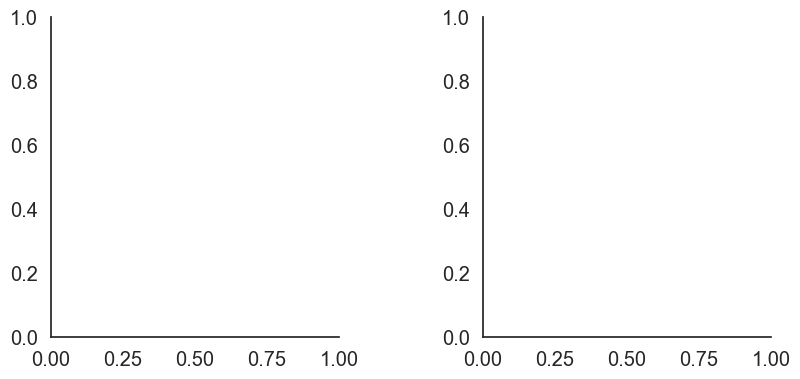

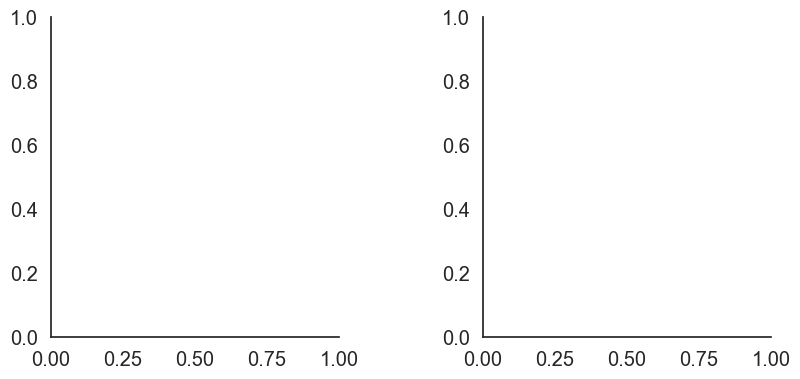

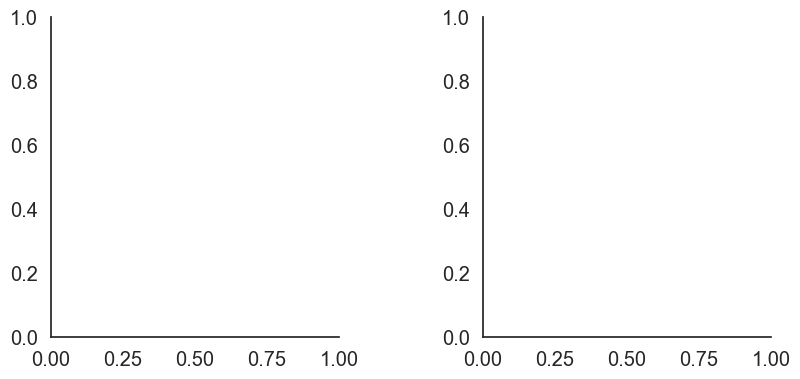

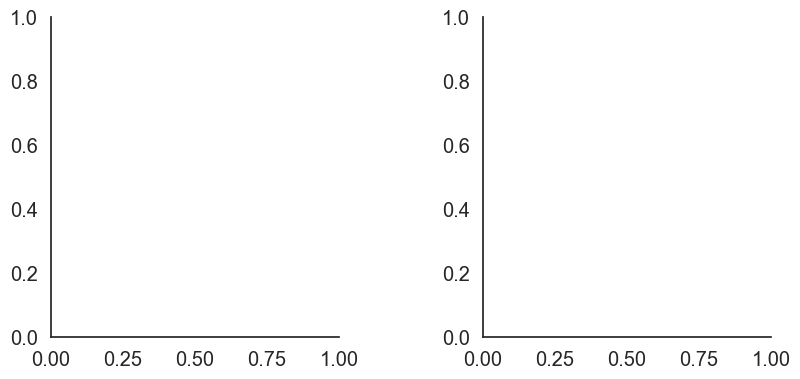

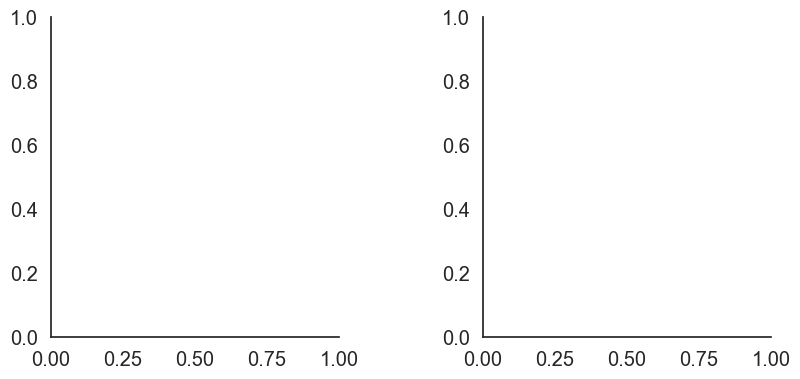

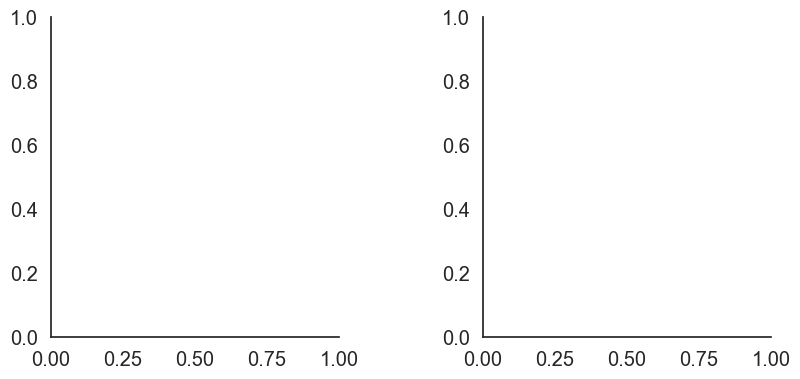

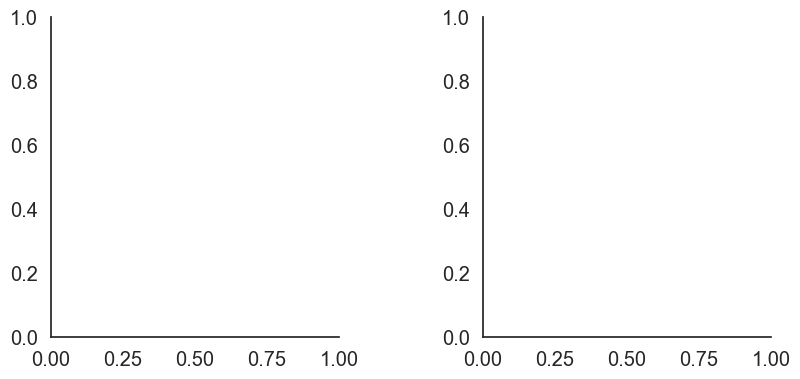

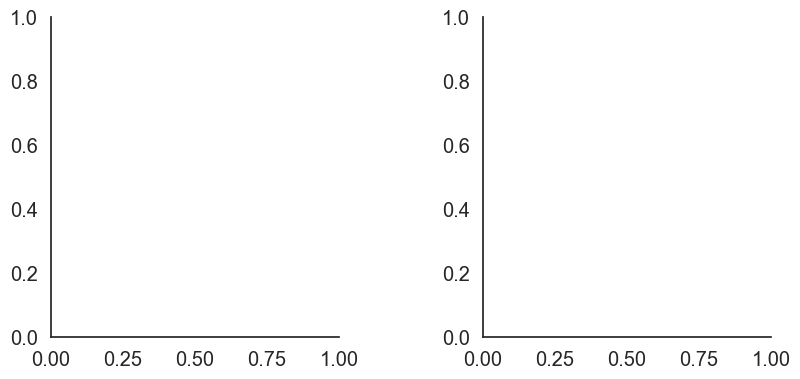

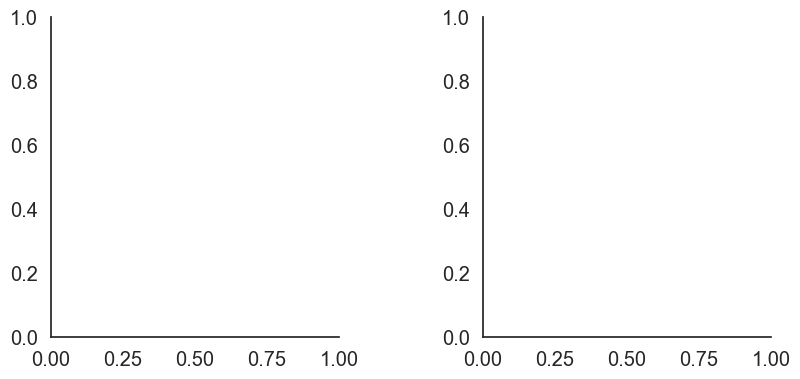

In [ ]:
# Extract necessary files for each session
use_responsive_only = False  # Change to False to use all neurons // Option to use only responsive neurons

for ind, recordingDate in enumerate(info.recordingList.recordingDate):
   # if all_neurons folder is not exist in the naalysis path
   allNeurons_path = os.path.join(info.recordingList.analysispathname[ind], 'all_neurons')
   try:
      if info.recordingList.loc[ind, 'pupilExtracted'] == 1:# 
         print(str(ind) + ': Creating: ' + info.recordingList.analysispathname[ind])
         #Create a huge dictionary with all cells and parameters for each cell
         pathname = info.recordingList.analysispathname[ind]
         # create the folder if it does not exist
         if not os.path.exists(pathname):
            os.makedirs(pathname)

      ########## GET BEHAVIOURAL OUTPUT
         filenameCSV = info.recordingList.analysispathname[ind] + info.recordingList.sessionName[ind] + '_CorrectedeventTimes.csv'
         filenameCSV = [f for f in glob.glob(filenameCSV)]    
         behData     = pd.read_csv(filenameCSV[0], header=0)
         visTimes    = behData['stimulusOnsetTime'] + behData['trialOffsets']
         rewardTimes = behData['rewardTime'] + behData['trialOffsets']
         choice      = behData['choice']
         choiceTimes = behData['choiceStartTime'] + behData['trialOffsets']
         stimSide = behData['correctResponse']

         # get recording side 
         tiff_path    = info.recordingList.imagingTiffFileNames[ind]
         behData_aug = mfun.add_trial_side_info(behData, tiff_path)

         recordingSideStim = behData_aug['recordingSideStim']
         biasStim = behData_aug['biasStim']
         recordingSideChoice = behData_aug['recordingSideChoice']
         biasChoice = behData_aug['biasChoice']
      
         # Make a variable for rewarded trials
         rewarded    =  behData['rewardTime'].notna() # True for rewarded which also means correct response
         # Calculate reward Time for non-rewarded Trials
         choiceCompleteTimes = behData['choiceCompleteTime'] + behData['trialOffsets']
         diff_time = np.nanmean(rewardTimes -choiceTimes)
         nan_indices = np.isnan(rewardTimes) # unrewarded trials
         rewardTimes[nan_indices] = choiceCompleteTimes[nan_indices] + diff_time
         
         # Create variable stimulus that takes the non-zero value of contrastLeft or contrastRight
         stimulus = np.where(behData['contrastLeft'] != 0, -behData['contrastLeft'], behData['contrastRight'])

         # Get the stim start times 
         filenameTXT = os.path.join(info.recordingList.path[ind],'twoP') +'\*_imaging_frames.txt'
         filenameTXT= [f for f in glob.glob(filenameTXT)]    
         frame_clock = pd.read_csv(filenameTXT[0],  header= None)
            
         stimFrameTimes    = np.ceil(visTimes*fps) #utils.stim_start_frame_Dual2Psetup (frame_clock, visTimes)
         rewardFrameTimes  = np.ceil(rewardTimes*fps)
         choiceFrameTimes  = np.ceil(choiceTimes*fps)

      ########## GET PUPIL IMAGING DATA ( in csv)
         pupilRawCSV = pd.read_csv(os.path.join(pupilExtractedPath, info.recordingList.sessionName[ind],
                                                info.recordingList.sessionName[ind] +'_pupil_analysis_results_26022026.csv'))
         pupilTrace   = pupilRawCSV['circumference_px'].values
         # fig, ax = plt.subplots(figsize=(10, 4))
         # ax.plot(pupilTrace, color='blue')
         # ax.set_xlim(0, 300*fps)
         # plt.show()
         # print(' Done after pupilTrace')
       
      ########## CREATE INTERESTED TRIAL TYPES
         tTypesName, tTypes = mfun.build_trial_types(
                                                      behData,
                                                      rewarded,
                                                      choice,
                                                      stimSide,
                                                      stimulus,
                                                      recordingSideStim,
                                                      biasStim,
                                                      recordingSideChoice,
                                                      biasChoice
                                                      )

         ########## CREATE TRIAL TYPE SPECIFIC TRACES
         # --- FULL pupil TRACE ---
         pupilTrace_reward, pupilTrace_mean_reward = {}, {}
         pupilTrace_stimuli, pupilTrace_mean_stimuli = {}, {}
         pupilTrace_choice, pupilTrace_mean_choice = {}, {}
         pupil_mean_stimuli, pupil_mean_reward, pupil_mean_choice = {}, {}, {}
         pupilTrace_mean_stimuli_baseline, pupilTrace_mean_reward_baseline, pupilTrace_mean_choice_baseline = {}, {}, {}
         for indx, t in enumerate(tTypesName):
            # For reward
            selected_indices = [rewardFrameTimes[i] for i in np.where((tTypes[indx]==True)& (~np.isnan(rewardFrameTimes)))[0]]  
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_reward[t] = utils.singleTrace_splitter(pupilTrace,selected_indices, pre_frames, post_frames)  # Cell x time x trial
            pupilTrace_mean_reward[t] = np.mean(pupilTrace_reward[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_reward[t] = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames - int(np.ceil(1000.0/fRate))): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_reward_baseline[t] = (pupilTrace_mean_reward[t] - baseline)  if len(selected_indices)>2 else None
            print(f'Completed reward for {t} - number of trials: {len(selected_indices)}')
             # For stimuli
            selected_indices = [stimFrameTimes[i] for i in np.where(tTypes[indx]==True)[0]]
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_stimuli[t] = utils.singleTrace_splitter(pupilTrace, selected_indices, pre_frames, post_frames) # Cell x time x trial 
            pupilTrace_mean_stimuli[t] = np.mean(pupilTrace_stimuli[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_stimuli[t] = np.nanmean(pupilTrace_mean_stimuli[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_stimuli[t][:, (pre_frames - int(np.ceil(1000.0/fRate))): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_stimuli_baseline[t] = (pupilTrace_mean_stimuli[t] - baseline) if len(selected_indices)>2 else None

            # For choice
            selected_indices = [choiceFrameTimes[i] for i in np.where((tTypes[indx]==True)& (~np.isnan(choiceFrameTimes)))[0]] 
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_choice[t] = utils.singleTrace_splitter(pupilTrace, selected_indices, pre_frames, post_frames) # Cell x time x trial
            pupilTrace_mean_choice[t] = np.mean(pupilTrace_choice[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_choice[t] = np.nanmean(pupilTrace_mean_choice[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_choice[t][:, (pre_frames - int(np.ceil(1000.0/fRate))): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_choice_baseline[t] = (pupilTrace_mean_choice[t] - baseline) if len(selected_indices)>2 else None


           # --- DO WE NEED Z-SCORED ? IF SO ADD ACCORDINGLY---

         print('DONE')
         ########## LETS SAVE VARIABLES

         # Determine subfolder based on use_responsive_only
         subfolder = 'responsive_neurons' if use_responsive_only else 'all_neurons'
         subfolder_path = os.path.join(pathname, subfolder)
         os.makedirs(subfolder_path, exist_ok=True)

         # Save params in the appropriate subfolder
         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_reward,pupilTrace_stimuli, pupilTrace_choice] , f)

         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace_mean.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_mean_reward,
                        pupilTrace_mean_stimuli,
                        pupilTrace_mean_choice ] , f)

         filenameINFO = os.path.join(subfolder_path, 'pupil-pupil_mean.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupil_mean_reward,
                        pupil_mean_stimuli,
                        pupil_mean_choice ] , f)
            
         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace_mean_baseline.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_mean_reward_baseline,
                        pupilTrace_mean_stimuli_baseline,
                        pupilTrace_mean_choice_baseline ] , f)
            
         print('Done - after saving')
         ########## LETS CREATE SOME HEATMAPS
         colormap = 'viridis'
         selectedSession = 'WithinSession'
         
         savefigname = 'Heatmap-reward_' + str(duration[0]) + 'sec'
         analysis_params = ['Rewarded', 'Unrewarded']
         pfun.heatmap_sessions(pupilTrace_mean_reward, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params)  
         plt.close()
                        
         savefigname = 'Heatmap-choice_' + str(duration[0]) + 'sec'
         analysis_params = ['Left Choices','Right Choices']
         pfun.heatmap_sessions(pupilTrace_mean_choice, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params) 
         plt.close()

         savefigname = 'Heatmap-stimuli_' + str(duration[0]) + 'sec'
         analysis_params = ['0.0625','0.125', '0.25', '0.5', '0']
         pfun.heatmap_sessions(pupilTrace_mean_stimuli, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params) 
         plt.close()
         print('Done - after heatmap')

         ########## LETS CREATE SOME LINEPLOTS for Average Traces
         zscoreRun = False 
         baseline_subtract = [-1.0, 0.0]  # Baseline window: 1 second before stimulus onset

         # Get animal number and session info
         session_name = info.recordingList.sessionName[ind]
         title_prefix = f'{session_name}'

         colormap = ['red', 'black']
         savefigname = 'LinePlot-mean-reward_' + str(duration[0]) + 'sec'
         analysis_params = ['Rewarded', 'Unrewarded']
         pfun.lineplot_sessions(pupilTrace_mean_reward, analysis_params, colormap,
                              duration, zscoreRun, savefigname, subfolder_path, baseline_subtract, 
                              title=f'{title_prefix} - Rewarded vs Unrewarded / reward aligned') 
         plt.close()

         colormap = ['blue', 'red']
         savefigname = 'LinePlot-mean-choice_' + str(duration[0]) + 'sec'
         analysis_params = ['Left Choices','Right Choices']
         pfun.lineplot_sessions(pupilTrace_mean_choice, analysis_params, colormap,
                              duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                              title=f'{title_prefix} - Choice side / choice aligned')
         plt.close()

         ###### CONTRAST - Stimulus Aligned - Excited & inhibited cells separately
         colormap = 'viridis'
         analysis_params = ['0.5 Rewarded', '0.25 Rewarded','0.125 Rewarded','0.0625 Rewarded','0 Rewarded']
         pfun.set_figure()
         fig = plt.figure(constrained_layout=False, figsize=(8, 4)) # 8,11 for full A4 page

         gs_contrast  = fig.add_gridspec(ncols=2, nrows=1, bottom=0, top=0.8, left=0.05, right=0.95,
                                    wspace=0.5, hspace=0.6)
         ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}

         pfun.lineplot_sessions(pupilTrace_mean_stimuli, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'{title_prefix}: excited cells', axes=ax_contrast[0], 
                                       cellSelection = pupil_mean_stimuli['0.5 Rewarded']>0) 

         pfun.lineplot_sessions(pupilTrace_mean_stimuli, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'inhibited cells', axes=ax_contrast[1], 
                                       cellSelection = pupil_mean_stimuli['0.5 Rewarded']<0) 
         # save the figure
         savefigname = 'LinePlot_Contrast-stimuliAligned-rewarded'
         pfun.save_figure(savefigname, subfolder_path)
         plt.close()

         ###### CONTRAST - Reward Aligned - Excited & inhibited cells separately
         colormap = 'viridis'
         analysis_params = ['0.5 Rewarded', '0.25 Rewarded','0.125 Rewarded','0.0625 Rewarded','0 Rewarded']
         pfun.set_figure()
         fig = plt.figure(constrained_layout=False, figsize=(8, 4)) # 8,11 for full A4 page

         gs_contrast  = fig.add_gridspec(ncols=2, nrows=1, bottom=0, top=0.8, left=0.05, right=0.95,
                                    wspace=0.5, hspace=0.6)
         ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}

         pfun.lineplot_sessions(pupilTrace_mean_reward_baseline, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'{title_prefix}: exited cells', axes=ax_contrast[0], 
                                       cellSelection = pupilTrace_mean_stimuli['0.5 Rewarded']>0) 
         ax_contrast[0].legend().set_visible(False)

         pfun.lineplot_sessions(pupilTrace_mean_reward_baseline, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'inhibited cells', axes=ax_contrast[1], 
                                       cellSelection = pupilTrace_mean_stimuli['0.5 Rewarded']<0) 
         # save the figure
         savefigname = 'LinePlot_Contrast-rewardAligned-rewarded'
         pfun.save_figure(savefigname, subfolder_path)
         plt.close()

         ###  CHOICE SIDE - Excited & inhibited cells separately
         colormap = ['blue', 'red']
         analysis_params = ['Left','Right']
         pfun.set_figure()
         fig = plt.figure(constrained_layout=False, figsize=(8, 6)) # 8,11 for full A4 page

         gs_contrast  = fig.add_gridspec(ncols=2, nrows=1, bottom=0, top=0.9, left=0.05, right=0.95,
                                       wspace=0.4, hspace=0.6)
         ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}


         pfun.lineplot_sessions(pupilTrace_mean_stimuli_baseline, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'{title_prefix} -excited cells', axes=ax_contrast[0], 
                                       cellSelection = pupil_mean_stimuli['0.5 Rewarded']>0) 
         ax_contrast[0].legend().set_visible(False)

         pfun.lineplot_sessions(pupilTrace_mean_stimuli_baseline, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'inhibited cells', axes=ax_contrast[1], 
                                       cellSelection = pupil_mean_stimuli['0.5 Rewarded']<0) 
         # save the figure
         savefigname = 'LinePlot_Choice-stimuliAligned-rewarded'
         pfun.save_figure(savefigname, subfolder_path)
         plt.close()

         print('Completed')
         info.recordingList.loc[ind,'analysisVariableExtracted'] = 1
   except Exception as e:
      print(f">>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing {info.recordingList.sessionName[ind]}: {e}")
# Add a line percentage of completion for the for loop
      print(f'Completed {ind+1}/{len(info.recordingList)} ({(ind+1)/len(info.recordingList)*100:.2f}%)')

In [26]:
indx

0

In [29]:
for indx, t in enumerate(tTypesName):
    # For reward
    selected_indices = [rewardFrameTimes[i] for i in np.where((tTypes[indx]==True)& (~np.isnan(rewardFrameTimes)))[0]]  
    selected_indices = [value for value in selected_indices if value == value]
    pupilTrace_reward[t] = utils.singleTrace_splitter(pupilTrace,selected_indices, pre_frames, post_frames)  # Cell x time x trial
    pupilTrace_mean_reward[t] = np.mean(pupilTrace_reward[t],2) if len(selected_indices)>2 else None # Cell x time
    pupil_mean_reward[t] = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
    baseline  = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames - int(np.ceil(1000.0/fRate))): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
    pupilTrace_mean_reward_baseline[t] = (pupilTrace_mean_reward[t] - baseline)  if len(selected_indices)>2 else None
    print(f'Completed reward for {t} - number of trials: {len(selected_indices)}')


Completed reward for Rewarded - number of trials: 173
Completed reward for Unrewarded - number of trials: 79
Completed reward for Left Choices - number of trials: 156
Completed reward for Right Choices - number of trials: 82
Completed reward for Rewarded Left - number of trials: 107
Completed reward for Rewarded Right - number of trials: 66
Completed reward for Unrewarded Left - number of trials: 49
Completed reward for Unrewarded Right - number of trials: 16
Completed reward for Left - number of trials: 127
Completed reward for Right - number of trials: 125
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 69
Completed reward for -0.25 - number of trials: 60
Completed reward for -0.5 - number of trials: 85
Completed reward for 0 - number of trials: 16
Completed reward for 0.0625 - number of trials: 0
Completed reward for 0.125 - number of trials: 0
Completed reward for 0.25 - number of trials: 0
Completed reward for 0.5 - number of tria

In [35]:
pupilTrace_reward['Rewarded'].shape

(1, 120, 173)

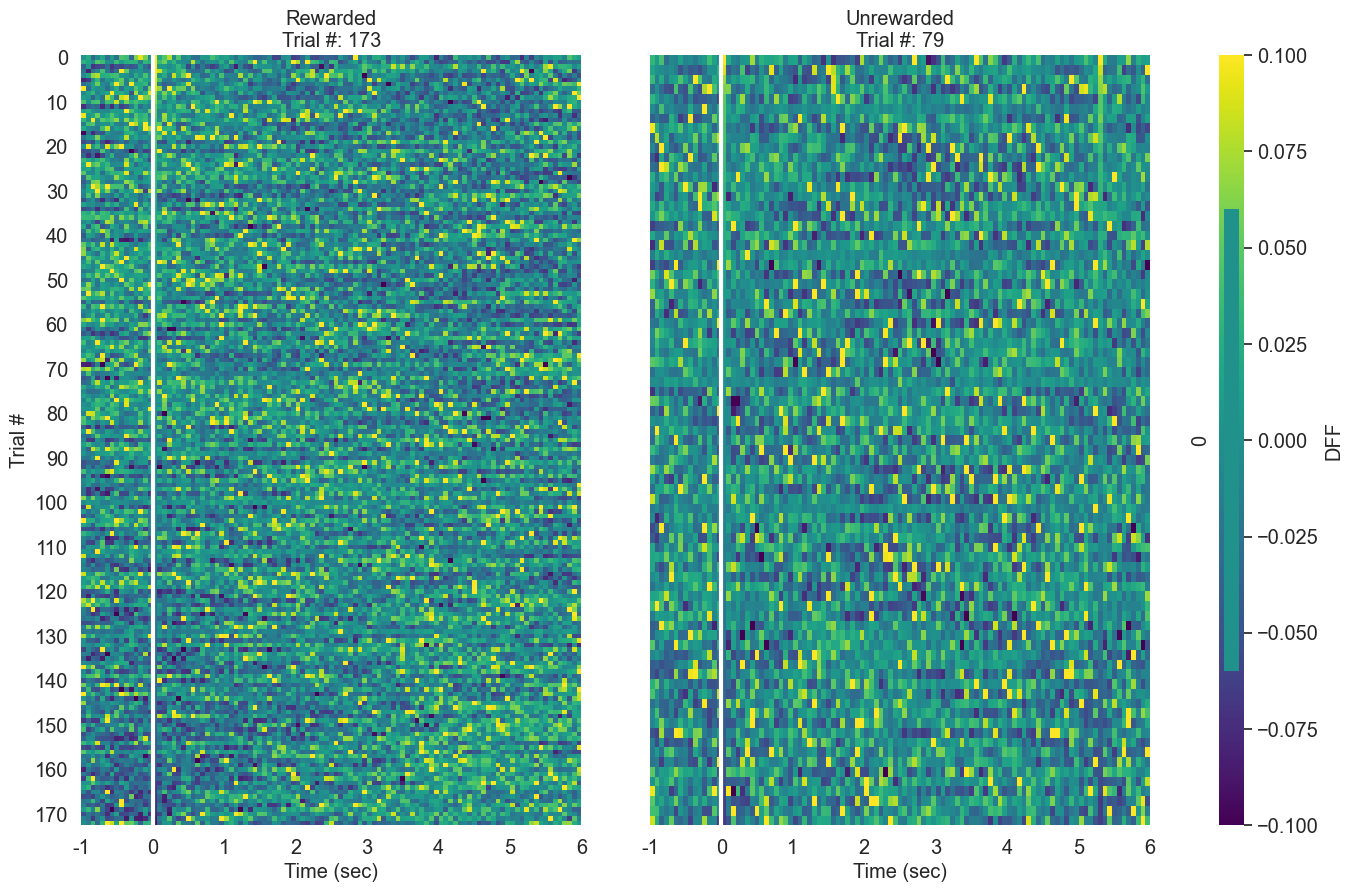

In [48]:
colormap = 'viridis'
selectedSession = 'WithinSession'

savefigname = 'Heatmap-reward_' + str(duration[0]) + 'sec'
analysis_params = ['Rewarded', 'Unrewarded']
pfun.heatmap_sessions(pupilTrace_reward, analysis_params, colormap,
                    selectedSession, duration, savefigname, subfolder_path, params = params) 


In [ ]:
#10> Save info into the analysis folder
filenameINFO = info.analysisPath + '\\infoForAnalysis.pkl'
with open(filenameINFO, 'wb') as f:
    pickle.dump(info, f)
print('All should be done!!')

# Save table as CSV
recordingList = info.recordingList
recordingList.to_csv( info.analysisPath +'\\recordingList.csv', index=False)